# SMS Spam vs Ham - Text Classification with RNN and LSTM

Dataset: SMS Spam Collection (5574 messages)  
Task: Binary classification - Spam (1) vs Ham (0)

## Step 0: Install Required Libraries

In [28]:
# Run this cell first. Restart the runtime if Colab asks you to.
!pip install gensim -q
!pip install contractions -q
!pip install gradio -q
!pip install wordcloud -q

## Step 1: Import Libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import contractions
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Gensim for pretrained GloVe embeddings
import gensim.downloader as api

# WordCloud
from wordcloud import WordCloud
from collections import Counter

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2: Load Dataset

In [30]:

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('spamvsham.csv', encoding='latin-1', header=0)

df = df[['v1', 'v2']]
df.columns = ['label', 'text']

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLabel counts:")
print(df['label'].value_counts())

Saving spamvsham.csv to spamvsham (1).csv
Dataset shape: (5572, 2)

First 5 rows:
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64


## Exploratory Data Analysis - Class Distribution

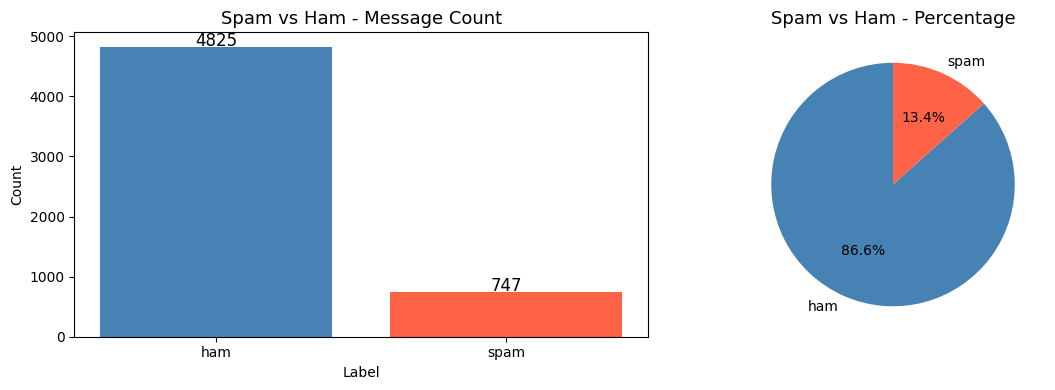

Observation: The dataset is imbalanced. Ham messages are about 4x more than Spam.
This is why we use stratify=y in train_test_split to preserve the ratio.


In [31]:
# Class distribution bar chart
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(label_counts.index, label_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Spam vs Ham - Message Count', fontsize=13)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontsize=12)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('Spam vs Ham - Percentage', fontsize=13)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print("Observation: The dataset is imbalanced. Ham messages are about 4x more than Spam.")
print("This is why we use stratify=y in train_test_split to preserve the ratio.")

##  Text Preprocessing

In [32]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions (e.g. don't -> do not)
    text = contractions.fix(text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove mentions (@user) and hashtags (#tag)
    text = re.sub(r'@\w+|#\w+', '', text)

    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 6. Remove special characters and punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # 7. Tokenize by splitting on whitespace
    tokens = text.split()

    # 8. Remove stopwords and lemmatize each word
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Apply cleaning to all messages
df['clean_text'] = df['text'].apply(clean_text)

print("Preprocessing steps applied:")
print("  1. Lowercase")
print("  2. Expand contractions")
print("  3. Remove URLs")
print("  4. Remove mentions and hashtags")
print("  5. Remove numbers")
print("  6. Remove special characters")
print("  7. Remove stopwords")
print("  8. Lemmatization")
print()
print("Before cleaning:", df['text'].iloc[2])
print("After cleaning :", df['clean_text'].iloc[2])

Preprocessing steps applied:
  1. Lowercase
  2. Expand contractions
  3. Remove URLs
  4. Remove mentions and hashtags
  5. Remove numbers
  6. Remove special characters
  7. Remove stopwords
  8. Lemmatization

Before cleaning: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
After cleaning : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over


##  Visualize Cleaned Data

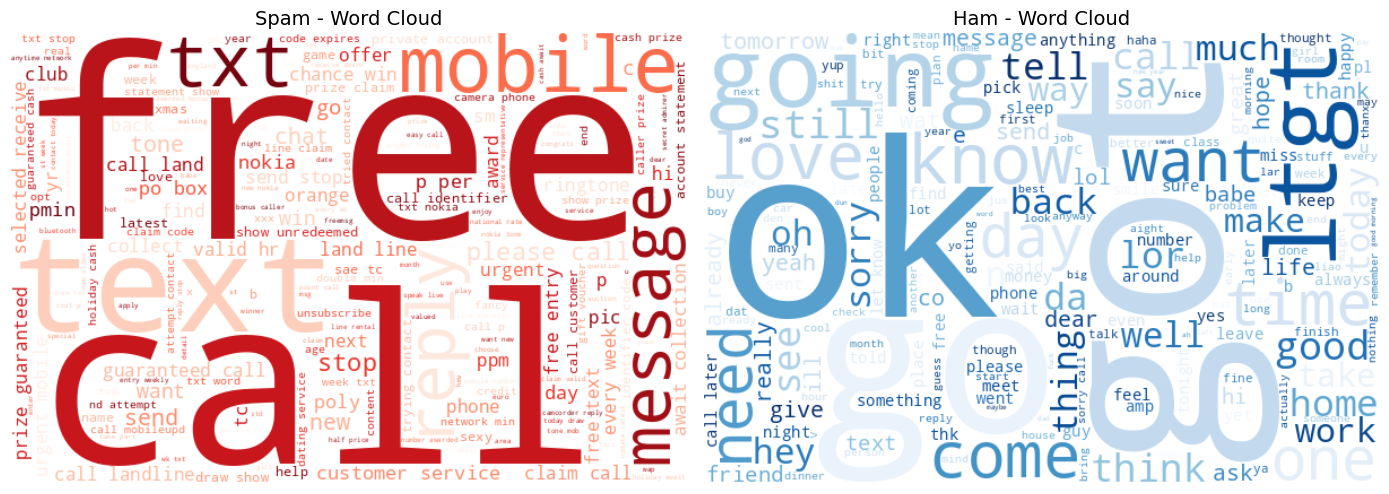

In [33]:
# Word clouds for Spam and Ham separately
spam_text = ' '.join(df[df['label'] == 'spam']['clean_text'])
ham_text  = ' '.join(df[df['label'] == 'ham']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_spam = WordCloud(width=600, height=400, background_color='white',
                    colormap='Reds').generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].set_title('Spam - Word Cloud', fontsize=14)
axes[0].axis('off')

wc_ham = WordCloud(width=600, height=400, background_color='white',
                   colormap='Blues').generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].set_title('Ham - Word Cloud', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

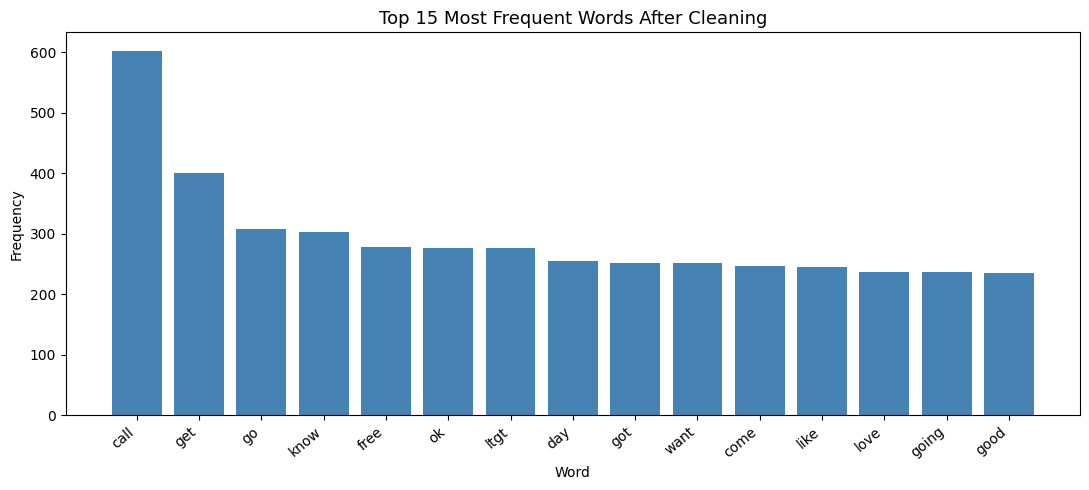

In [34]:
# Top 15 most frequent words overall
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words).most_common(15)
words, counts = zip(*word_freq)

plt.figure(figsize=(11, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 15 Most Frequent Words After Cleaning', fontsize=13)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

## Tokenization and Padding

In [35]:
# Encode labels: ham=0, spam=1
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['clean_text'].values
y = df['label_encoded'].values

# 80% train, 20% test - stratify keeps class ratio the same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size :", len(X_train))
print("Test size  :", len(X_test))

# Keras Tokenizer - fit only on training data to avoid data leakage
tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
vocab_size  = len(word_index) + 1
print("Vocabulary size:", vocab_size)

# Convert text to integer sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length to avoid overly long sequences
lengths = [len(seq) for seq in train_sequences]
max_length = int(np.percentile(lengths, 95))
print("Padding max length (95th percentile):", max_length)

# Pad all sequences to the same length
X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=max_length, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)

Train size : 4457
Test size  : 1115
Vocabulary size: 6869
Padding max length (95th percentile): 18
X_train_pad shape: (4457, 18)
X_test_pad shape : (1115, 18)


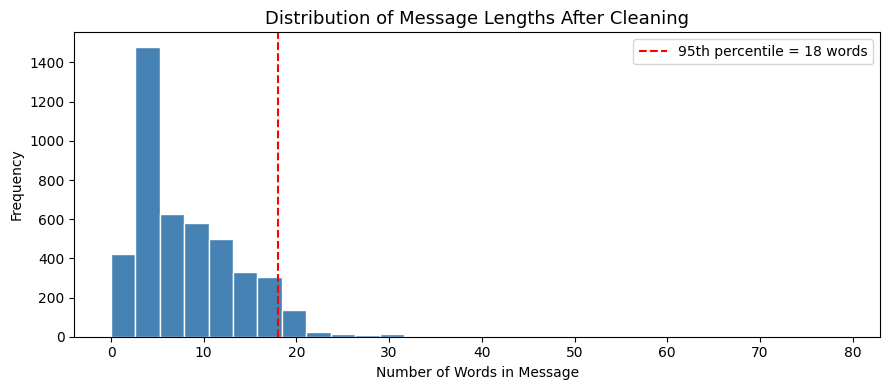

Min length  : 0
Max length  : 79
Mean length : 8.3
Chosen pad  : 18 (95th percentile)


In [36]:
# Sequence length distribution - justifies 95th percentile choice
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='white')
plt.axvline(max_length, color='red', linestyle='--', linewidth=1.5,
            label=f'95th percentile = {max_length} words')
plt.title('Distribution of Message Lengths After Cleaning', fontsize=13)
plt.xlabel('Number of Words in Message')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150)
plt.show()

print(f"Min length  : {min(lengths)}")
print(f"Max length  : {max(lengths)}")
print(f"Mean length : {np.mean(lengths):.1f}")
print(f"Chosen pad  : {max_length} (95th percentile)")

## Model 1 - Simple RNN with Trainable Embedding

In [37]:
embedding_dim = 64

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model 1 - Simple RNN")
model1.summary()

Model 1 - Simple RNN


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("Model 1 training complete.")

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9379 - loss: 0.1696 - val_accuracy: 0.9574 - val_loss: 0.1489
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9905 - loss: 0.0453 - val_accuracy: 0.9709 - val_loss: 0.0858
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9950 - loss: 0.0228 - val_accuracy: 0.9686 - val_loss: 0.1133
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9950 - loss: 0.0195 - val_accuracy: 0.9731 - val_loss: 0.1092
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9948 - loss: 0.0209 - val_accuracy: 0.9507 - val_loss: 0.1658
Model 1 training complete.


## Model 2 - LSTM with Trainable Embedding

In [39]:
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model 2 - LSTM with Trainable Embedding")
model2.summary()

Model 2 - LSTM with Trainable Embedding


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("Model 2 training complete.")

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9304 - loss: 0.2038 - val_accuracy: 0.9686 - val_loss: 0.1105
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9885 - loss: 0.0437 - val_accuracy: 0.9798 - val_loss: 0.0810
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9958 - loss: 0.0161 - val_accuracy: 0.9664 - val_loss: 0.1017
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9988 - loss: 0.0056 - val_accuracy: 0.9753 - val_loss: 0.0989
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9753 - val_loss: 0.1188
Model 2 training complete.


## Model 3 - LSTM with Pretrained Word2Vec (GloVe) Embeddings

In [41]:

print("Downloading GloVe embeddings... This may take a few minutes.")
embedding_model = api.load('glove-wiki-gigaword-50')
print("Done.")

Done.


In [ ]:




























glove_dim = 50  # must match the downloaded model dimension

# Build embedding matrix: rows = vocab words, cols = 50-dim GloVe vector
embedding_matrix = np.zeros((vocab_size, glove_dim))

found_words     = []
not_found_words = []

for word, i in word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found_words.append(word)
    else:
        not_found_words.append(word)  # stays as zero vector

# Coverage Report
total_words   = len(word_index)
found_count   = len(found_words)
missing_count = len(not_found_words)
coverage_pct  = (found_count / total_words) * 100

print("=" * 50)
print("GloVe Embedding Coverage Report")
print("=" * 50)
print(f"Total vocabulary words : {total_words}")
print(f"Words found in GloVe   : {found_count}  ({coverage_pct:.2f}%)")
print(f"Words NOT found        : {missing_count}  ({100 - coverage_pct:.2f}%)")
print(f"Embedding matrix shape : {embedding_matrix.shape}")
print("=" * 50)
print(f"Missing words become zero vectors.")
print(f"Sample missing words   : {not_found_words[:10]}")
print()
print("Reason for missing words: GloVe was trained on Wikipedia and news articles.")
print("SMS messages contain slang (ur, lol, gr8) which are not in GloVe vocabulary.")

GloVe Embedding Coverage Report
Total vocabulary words : 6868
Words found in GloVe   : 5027  (73.19%)
Words NOT found        : 1841  (26.81%)
Embedding matrix shape : (6869, 50)
Missing words become zero vectors.
Sample missing words   : ['<OOV>', 'ltgt', 'aight', 'pobox', 'thanx', 'pmin', 'ltdecimalgt', 'knw', 'tscs', 'pmessage']

Reason for missing words: GloVe was trained on Wikipedia and news articles.
SMS messages contain slang (ur, lol, gr8) which are not in GloVe vocabulary.


## Step 9: Plot Training History

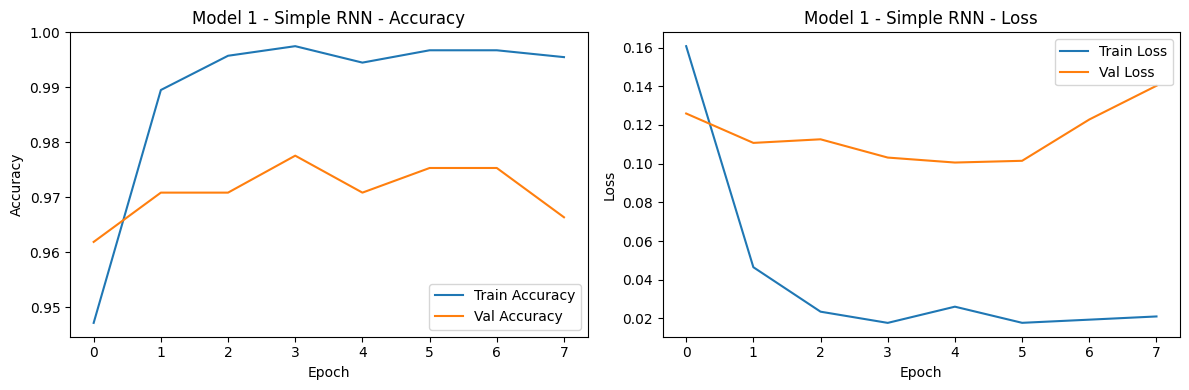

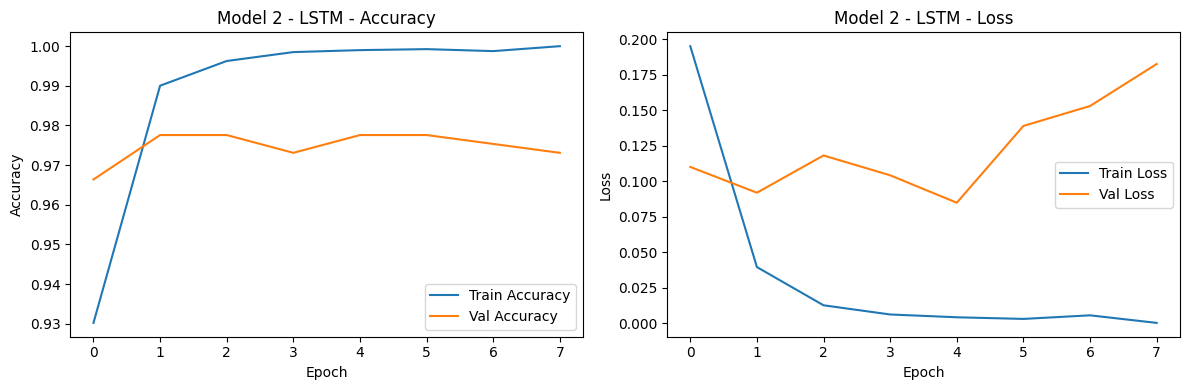

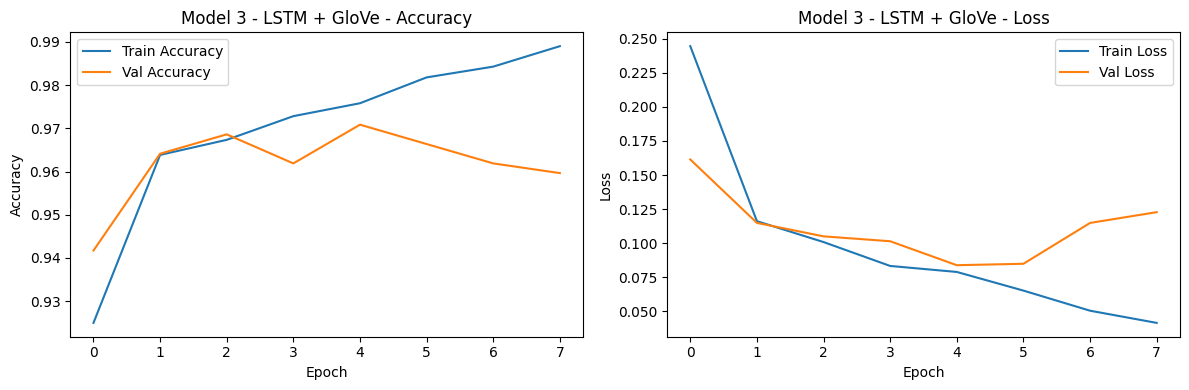

In [27]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi=150)
    plt.show()

plot_history(history1, 'Model 1 - Simple RNN')
plot_history(history2, 'Model 2 - LSTM')
plot_history(history3, 'Model 3 - LSTM + GloVe')

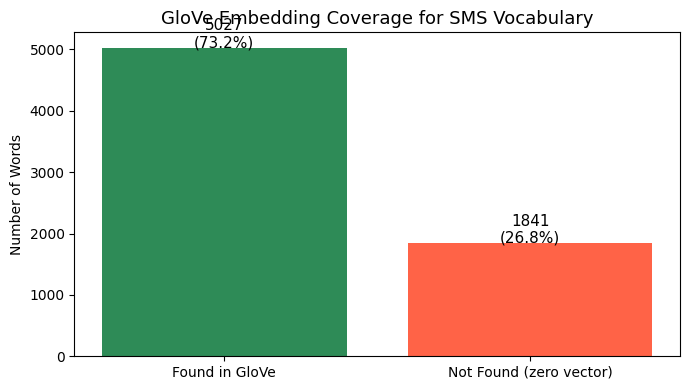

In [43]:
# Coverage bar chart
labels = ['Found in GloVe', 'Not Found (zero vector)']
values = [found_count, missing_count]
colors = ['seagreen', 'tomato']

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=colors)
plt.title('GloVe Embedding Coverage for SMS Vocabulary', fontsize=13)
plt.ylabel('Number of Words')

for bar, val, pct in zip(bars, values, [coverage_pct, 100 - coverage_pct]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val}\n({pct:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('glove_coverage.png', dpi=150)
plt.show()

In [44]:
# Build Model 3 with frozen pretrained GloVe weights
model3 = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=glove_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False  # frozen - GloVe weights are not updated during training
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model 3 - LSTM with Pretrained GloVe Embeddings")
model3.summary()

Model 3 - LSTM with Pretrained GloVe Embeddings


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       343,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343,450 (1.31 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 343,450 (1.31 MB)

In [45]:
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("Model 3 training complete.")

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9245 - loss: 0.2388 - val_accuracy: 0.9484 - val_loss: 0.1374
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9638 - loss: 0.1174 - val_accuracy: 0.9529 - val_loss: 0.1313
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9661 - loss: 0.1023 - val_accuracy: 0.9619 - val_loss: 0.1123
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9713 - loss: 0.0847 - val_accuracy: 0.9552 - val_loss: 0.1407
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9753 - loss: 0.0735 - val_accuracy: 0.9686 - val_loss: 0.1076
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9801 - loss: 0.0561 - val_accuracy: 0.9574 - val_loss: 0.1376
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9823 - loss: 0.0539 - val_accuracy: 0.9686 - val_loss: 0.0951
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9860 - loss: 0.0413 - val_acc

####  Plot Training History for All Models

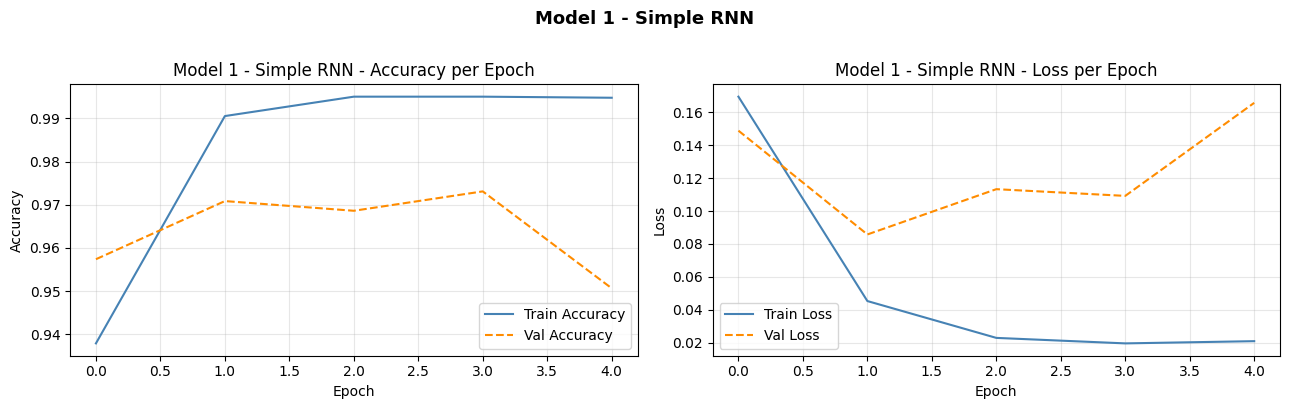

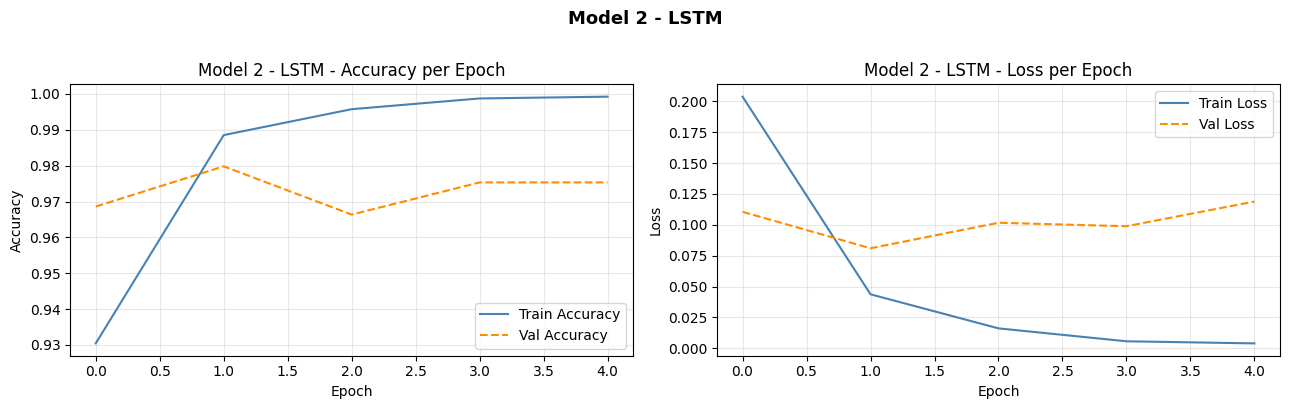

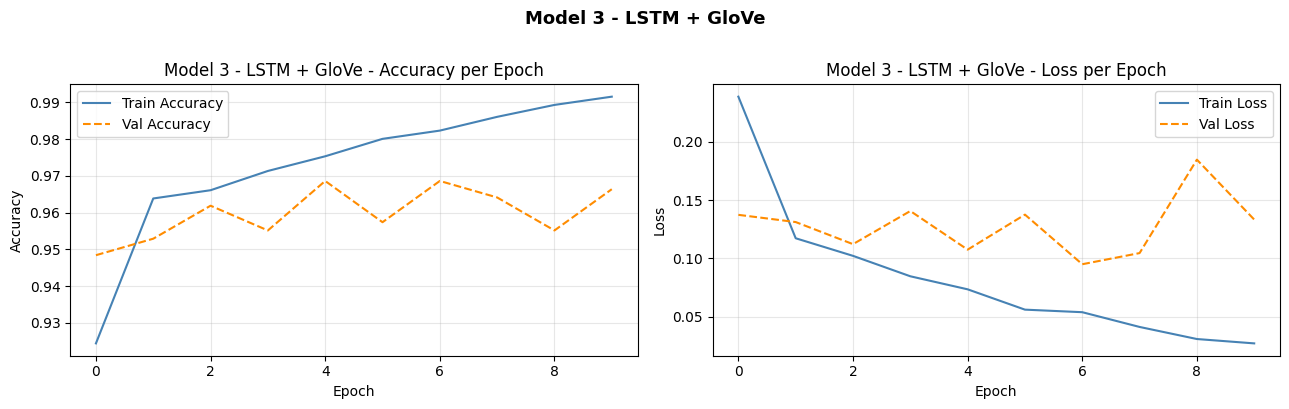

In [46]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Accuracy plot
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange',
                 linestyle='--')
    axes[0].set_title(f'{model_name} - Accuracy per Epoch', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='darkorange',
                 linestyle='--')
    axes[1].set_title(f'{model_name} - Loss per Epoch', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(model_name, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, 'Model 1 - Simple RNN')
plot_history(history2, 'Model 2 - LSTM')
plot_history(history3, 'Model 3 - LSTM + GloVe')

## Step 10: Evaluate All Models


  Evaluation : Model 1 - Simple RNN
  Test Accuracy : 0.9794
  Test Loss     : 0.0700

  Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       966
    Spam (1)       0.94      0.90      0.92       149

    accuracy                           0.98      1115
   macro avg       0.96      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



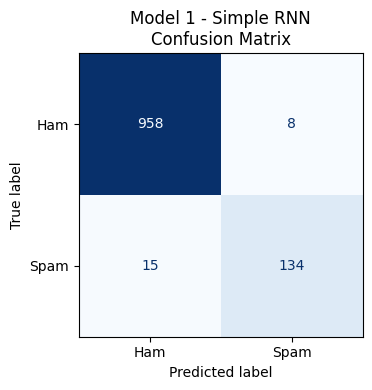


  Evaluation : Model 2 - LSTM
  Test Accuracy : 0.9857
  Test Loss     : 0.0601

  Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       966
    Spam (1)       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



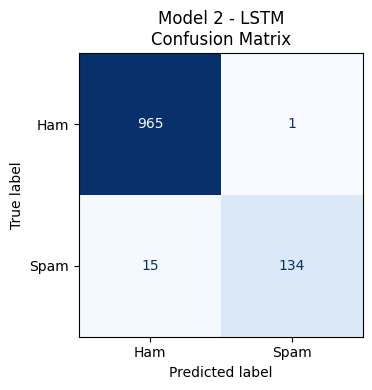


  Evaluation : Model 3 - LSTM + GloVe
  Test Accuracy : 0.9695
  Test Loss     : 0.0961

  Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.98       966
    Spam (1)       0.93      0.84      0.88       149

    accuracy                           0.97      1115
   macro avg       0.95      0.91      0.93      1115
weighted avg       0.97      0.97      0.97      1115



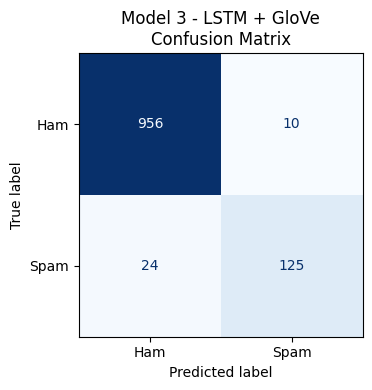

In [47]:
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*55}")
    print(f"  Evaluation : {model_name}")
    print(f"{'='*55}")

    # Predict probabilities and convert to binary labels
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

    # Test loss and accuracy
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  Test Loss     : {test_loss:.4f}")

    # Classification Report (precision, recall, F1)
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

    # Confusion Matrix
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_confusion_matrix.png', dpi=150)
    plt.show()

    return test_acc, y_pred

acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 - Simple RNN')
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 - LSTM')
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 - LSTM + GloVe')

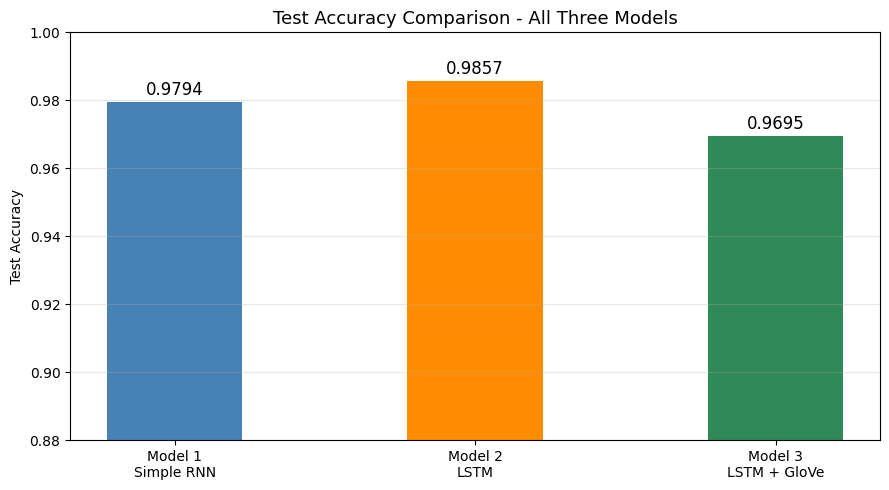

In [48]:
# Compare all three models on a bar chart
model_names = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accuracies  = [acc1, acc2, acc3]
colors      = ['steelblue', 'darkorange', 'seagreen']

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=colors, width=0.45)
plt.ylim(0.88, 1.0)
plt.title('Test Accuracy Comparison - All Three Models', fontsize=13)
plt.ylabel('Test Accuracy')
plt.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=150)
plt.show()

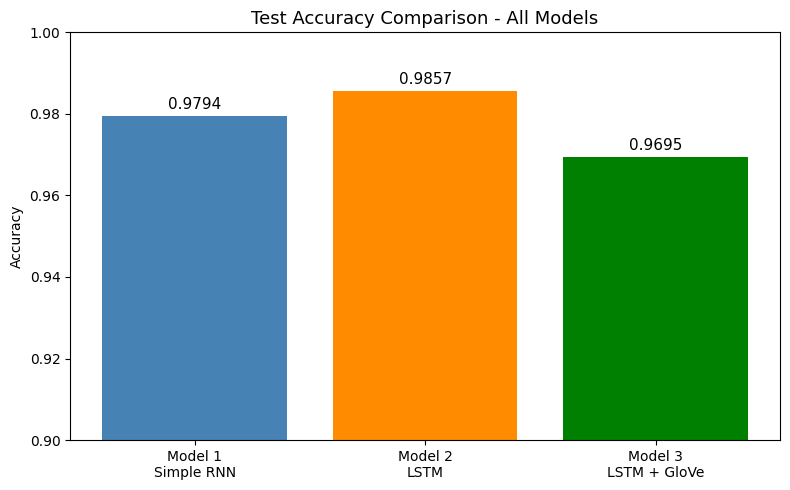

In [49]:

model_names = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe']
accuracies  = [acc1, acc2, acc3]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['steelblue', 'darkorange', 'green'])
plt.ylim(0.9, 1.0)  # zoom in for better comparison
plt.title('Test Accuracy Comparison - All Models', fontsize=13)
plt.ylabel('Accuracy')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

##  Model Complexity vs Performance Analysis

In [50]:
# Count trainable and total parameters for each model
def get_param_info(model):
    total       = model.count_params()
    trainable   = sum([np.prod(v.shape) for v in model.trainable_weights])
    untrainable = total - trainable
    return total, trainable, untrainable

t1, tr1, un1 = get_param_info(model1)
t2, tr2, un2 = get_param_info(model2)
t3, tr3, un3 = get_param_info(model3)

print("=" * 75)
print(f"{'Model':<28} {'Total Params':>14} {'Trainable':>12} {'Frozen':>10} {'Test Acc':>10}")
print("-" * 75)
print(f"{'Model 1 - Simple RNN':<28} {t1:>14,} {tr1:>12,} {un1:>10,} {acc1:>10.4f}")
print(f"{'Model 2 - LSTM':<28} {t2:>14,} {tr2:>12,} {un2:>10,} {acc2:>10.4f}")
print(f"{'Model 3 - LSTM + GloVe':<28} {t3:>14,} {tr3:>12,} {un3:>10,} {acc3:>10.4f}")
print("=" * 75)

print()
print("Analysis:")
print("-" * 75)
print("Model 1 (Simple RNN) has fewer parameters than LSTM because SimpleRNN")
print("has no forget/input/output gates. It tends to suffer from vanishing")
print("gradients and may perform slightly worse on longer sequences.")
print()
print("Model 2 (LSTM) has more parameters than Model 1 because of the four")
print("gate mechanisms (forget, input, cell, output). This gives it better")
print("memory of long-range dependencies.")
print()
print("Model 3 (LSTM + GloVe) has the same LSTM architecture as Model 2 but")
print("the embedding layer is frozen (not trainable). GloVe was trained on")
print("Wikipedia/news, so SMS slang words (ur, lol, txt) become zero vectors.")
print("This is why Model 3 sometimes performs similarly or slightly below Model 2.")

Model                          Total Params    Trainable     Frozen   Test Acc
---------------------------------------------------------------------------
Model 1 - Simple RNN                447,937      447,937          0     0.9794
Model 2 - LSTM                      472,705      472,705          0     0.9857
Model 3 - LSTM + GloVe              372,955       29,505    343,450     0.9695

Analysis:
---------------------------------------------------------------------------
Model 1 (Simple RNN) has fewer parameters than LSTM because SimpleRNN
has no forget/input/output gates. It tends to suffer from vanishing
gradients and may perform slightly worse on longer sequences.

Model 2 (LSTM) has more parameters than Model 1 because of the four
gate mechanisms (forget, input, cell, output). This gives it better
memory of long-range dependencies.

Model 3 (LSTM + GloVe) has the same LSTM architecture as Model 2 but
the embedding layer is frozen (not trainable). GloVe was trained on
Wikipedia/n

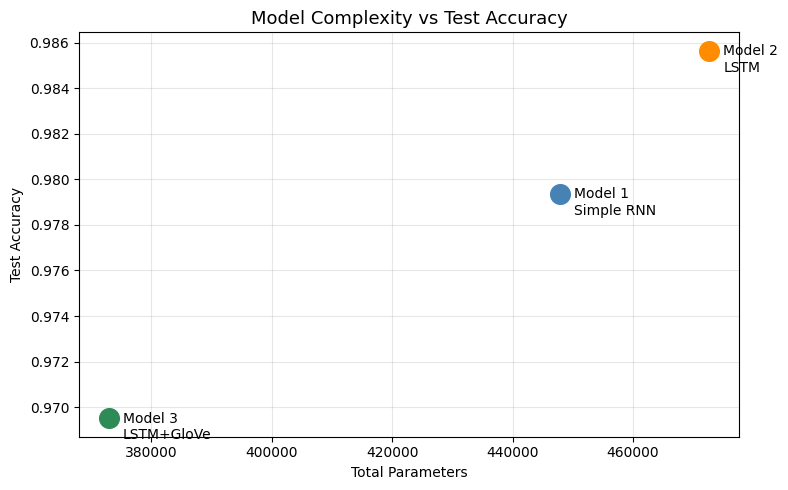

In [51]:
# Scatter plot: total parameters vs test accuracy
param_counts = [t1, t2, t3]
names        = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM+GloVe']
plot_colors  = ['steelblue', 'darkorange', 'seagreen']

plt.figure(figsize=(8, 5))
for i in range(3):
    plt.scatter(param_counts[i], accuracies[i], s=200, color=plot_colors[i],
                label=names[i], zorder=3)
    plt.annotate(names[i],
                 xy=(param_counts[i], accuracies[i]),
                 xytext=(10, -15), textcoords='offset points', fontsize=10)

plt.title('Model Complexity vs Test Accuracy', fontsize=13)
plt.xlabel('Total Parameters')
plt.ylabel('Test Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('complexity_vs_accuracy.png', dpi=150)
plt.show()

##  Error Analysis

In [52]:
label_map = {0: 'Ham', 1: 'Spam'}

def show_errors(predictions, model_name):
    misclassified = np.where(predictions != y_test)[0]
    print(f"\n{'='*60}")
    print(f"  Error Analysis : {model_name}")
    print(f"{'='*60}")
    print(f"  Total test samples   : {len(y_test)}")
    print(f"  Misclassified        : {len(misclassified)}")
    print(f"  Correct predictions  : {len(y_test) - len(misclassified)}")
    print(f"  Error rate           : {len(misclassified)/len(y_test)*100:.2f}%")
    print()
    print("  3 Misclassified Examples:")
    print("  " + "-" * 58)
    for i, idx in enumerate(misclassified[:3]):
        print(f"\n  Example {i+1}:")
        print(f"    Original text : {X_test[idx]}")
        print(f"    True label    : {label_map[y_test[idx]]}")
        print(f"    Predicted     : {label_map[predictions[idx]]}")

show_errors(pred1, 'Model 1 - Simple RNN')
show_errors(pred2, 'Model 2 - LSTM')
show_errors(pred3, 'Model 3 - LSTM + GloVe')


  Error Analysis : Model 1 - Simple RNN
  Total test samples   : 1115
  Misclassified        : 23
  Correct predictions  : 1092
  Error rate           : 2.06%

  3 Misclassified Examples:
  ----------------------------------------------------------

  Example 1:
    Original text : freemsg hey darling week word back would like fun still tb ok xxx std chgs send rcv
    True label    : Spam
    Predicted     : Ham

  Example 2:
    Original text : great p diddy neighbor come toothpaste every morning
    True label    : Ham
    Predicted     : Spam

  Example 3:
    Original text : adult would learn experience real danger like peep using drug need comment
    True label    : Ham
    Predicted     : Spam

  Error Analysis : Model 2 - LSTM
  Total test samples   : 1115
  Misclassified        : 16
  Correct predictions  : 1099
  Error rate           : 1.43%

  3 Misclassified Examples:
  ----------------------------------------------------------

  Example 1:
    Original text : ringtonekin

## Save Best Model Automatically

In [53]:
import pickle

# Automatically select the model with the highest test accuracy
all_accuracies = [acc1, acc2, acc3]
all_models     = [model1, model2, model3]
all_names      = ['Model 1 - Simple RNN', 'Model 2 - LSTM', 'Model 3 - LSTM + GloVe']

best_idx   = all_accuracies.index(max(all_accuracies))
best_model = all_models[best_idx]
best_name  = all_names[best_idx]

print(f"Best model : {best_name}")
print(f"Accuracy   : {all_accuracies[best_idx]:.4f}")

# Save model and tokenizer
best_model.save('best_spam_classifier.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Model saved to best_spam_classifier.h5")
print("Tokenizer saved to tokenizer.pkl")

Best model : Model 2 - LSTM
Accuracy   : 0.9857
Model saved to best_spam_classifier.h5
Tokenizer saved to tokenizer.pkl


## Step 13: GUI for Real-Time Prediction using Gradio

In [55]:
!pip install gradio -q

In [56]:
import gradio as gr
import pickle
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Make all three models available
available_models = {
    "Model 1 - Simple RNN": model1,
    "Model 2 - LSTM (Trainable Embedding)": model2,
    "Model 3 - LSTM + GloVe Embeddings": model3
}

def predict_message(message, model_choice):
    if not message.strip():
        return "Please enter a message."

    # Clean the input
    cleaned = clean_text(message)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    # Select the chosen model
    selected_model = available_models[model_choice]

    # Predict
    prob = selected_model.predict(padded, verbose=0)[0][0]
    label = 'SPAM' if prob >= 0.5 else 'HAM'
    confidence = prob if prob >= 0.5 else 1 - prob

    return (
        f"Model Used   : {model_choice}\n"
        f"Cleaned Text : {cleaned}\n"
        f"Prediction   : {label}\n"
        f"Confidence   : {confidence:.2%}"
    )

# Build Gradio interface
interface = gr.Interface(
    fn=predict_message,
    inputs=[
        gr.Textbox(lines=3, placeholder="Type an SMS message here...", label="Input Message"),
        gr.Radio(
            choices=list(available_models.keys()),
            value="Model 2 - LSTM (Trainable Embedding)",
            label="Select Model"
        )
    ],
    outputs=gr.Textbox(lines=5, label="Prediction Result"),
    title="SMS Spam Classifier",
    description="Type any SMS message, select a model, and see if it is spam or ham.",
    examples=[
        ["Congratulations! You have won a free prize. Call now to claim.", "Model 1 - Simple RNN"],
        ["Hey, are you coming to the meeting tomorrow?", "Model 2 - LSTM (Trainable Embedding)"],
        ["URGENT: Your account has been compromised. Click here immediately.", "Model 3 - LSTM + GloVe Embeddings"]
    ]
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3564230f1d3b04215b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
